In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from pathlib import Path 
import re
import cv2
import easyocr

In [2]:
import yaml
CONFIG_PATH = "../../configs/desktop.yaml" 
#環境によってパスを変える!!

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

device = cfg["runtime"]["device"]
sample_mode = cfg["runtime"]["sample_mode"]
use_gpu = cfg["runtime"]["use_gpu"]
print(cfg)


{'runtime': {'device': 'cuda', 'sample_mode': False, 'use_gpu': True}}


In [3]:
vod_title = "M8 vs. EDG - VALORANT Masters Santiago - SWISS"
video_path = Path(f"../../data/vods/{vod_title}.mp4")
csv_path = Path(f"../../data/processed/round_labels/{vod_title}_round_labels_fixed.csv")
df = pd.read_csv(csv_path)
reader = easyocr.Reader(["en"],gpu=use_gpu)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


In [18]:
df.columns

Index(['value', 'start_sec', 'end_sec', 'n_samples', 'mean_diff', 'min_diff',
       'max_diff', 'duration_sec', 't_sec', 't_min', 'left_score',
       'right_score', 'left_score_candidates', 'right_score_candidates',
       'score_total', 'round_no_from_score', 'map_no', 'round_no',
       'left_win_label', 'round_ocr_start_samples', 'round_ocr_end_samples',
       'round_no_ocr_start', 'round_no_ocr_end', 'prev_round_no_ocr',
       'prev_end_like', 'gap_from_prev', 'ocr_step', 'sequence_status',
       'action_candidate', 'fix_applied', 'needs_review', 'map',
       'start_timer_sec', 'start_search_offset_sec', 'search_start_sec',
       'start_timer_raws', 'attacker_win', 'defender_win'],
      dtype='str')

In [8]:
time_df = df[["start_sec","end_sec"]]

In [10]:
def normalize_timer_text(timer_text: str) -> str:
    if pd.isna(timer_text):
        return ""

    s = str(timer_text).strip()

    # OCRのよくある誤認補正
    s = s.replace("O", "0").replace("o", "0")
    s = s.replace("I", "1").replace("l", "1")

    # コロン誤認を補正
    s = s.replace(".", ":").replace(",", ":").replace(";", ":")

    # 空白を消す
    s = s.replace(" ", "")

    return s

def parse_timer_text_to_sec(timer_text: str):
    if pd.isna(timer_text):
        return np.nan

    s = normalize_timer_text(timer_text)

    # まず普通の m:ss を試す
    m = re.search(r'^(\d{1,2}):(\d{2})$', s)
    if m:
        minute = int(m.group(1))
        second = int(m.group(2))
        if second < 60:
            return minute * 60 + second
        return np.nan

    # コロンが落ちて数字だけになった場合
    digits = "".join(ch for ch in s if ch.isdigit())

    if len(digits) == 3:
        minute = int(digits[0])
        second = int(digits[1:])
    elif len(digits) == 4:
        minute = int(digits[:-2])
        second = int(digits[-2:])
    else:
        return np.nan

    if second >= 60:
        return np.nan

    return minute * 60 + second

def add_padding(img, pad=10, value=255):
    return cv2.copyMakeBorder(
        img,
        pad, pad, pad, pad,
        cv2.BORDER_CONSTANT,
        value=value
    )

def crop_timer_region(frame):
    """
    タイマー領域を切り出す
    """
    h, w = frame.shape[:2]

    # 仮の例: 画面上中央あたり
    x1 = int(w * 0.48)
    x2 = int(w * 0.52)
    y1 = int(h * 0.025)
    y2 = int(h * 0.06)

    return frame[y1:y2, x1:x2]


def preprocess_for_ocr(crop):
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)

    # 2値化
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return th


def read_timer_from_frame(frame, reader):
    crop = crop_timer_region(frame)
    proc = preprocess_for_ocr(crop)

    results = reader.readtext(proc, detail=0, paragraph=False)
    text = "".join(results).strip() if results else ""

    return {
        "timer_text": text,
        "timer_sec": parse_timer_text_to_sec(text),
        "raw_text": results
    }


def preprocess_timer_for_ocr(crop):
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return th

def read_timer_from_frame(frame, reader):
    if frame is None:
        return {
            "timer_text": "",
            "timer_sec": None,
            "raw_text": [],
        }
    crop = crop_timer_region(frame)
    proc = preprocess_timer_for_ocr(crop)
    results = reader.readtext(
        proc,
        allowlist="0123456789:.;,",
        detail=0,
        paragraph=False
    )
    text = "".join(results).strip() if results else ""
    timer_sec = parse_timer_text_to_sec(text)
    return {
        "timer_text": text,
        "timer_sec": timer_sec,
        "raw_text": results,
    }

def read_timer_near_sec(video_path, t_sec, reader, offsets=(-0.4, -0.2, 0.0, 0.2, 0.4)):
    timer_secs = []
    timer_texts = []

    for off in offsets:
        tt = t_sec + off
        if tt < 0:
            continue

        frame = read_frame_at_sec(video_path, tt)
        result = read_timer_from_frame(frame, reader)

        timer_sec = result.get("timer_sec")
        timer_text = result.get("timer_text")

        timer_texts.append(timer_text)

        if timer_sec is not None and not pd.isna(timer_sec):
            timer_secs.append(float(timer_sec))

    if len(timer_secs) == 0:
        return {
            "timer_sec": None,
            "timer_texts": timer_texts,
            "timer_secs": timer_secs,
        }

    timer_sec = float(np.median(timer_secs))

    return {
        "timer_sec": timer_sec,
        "timer_texts": timer_texts,
        "timer_secs": timer_secs,
    }

In [5]:
def read_frame_at_sec(video_path, t_sec):
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(t_sec * fps))
    ret, frame = cap.read()
    cap.release()

    if not ret:
        return None

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return frame

In [37]:
row = time_df.iloc[5]

start = row["start_sec"]
end = row["end_sec"]

frame = read_frame_at_sec(video_path,start)
texts = read_timer_near_sec(video_path,start,reader)
#search_start = start + texts["timer_sec"] - 1
#frame_start = read_frame_at_sec(video_path,search_start)


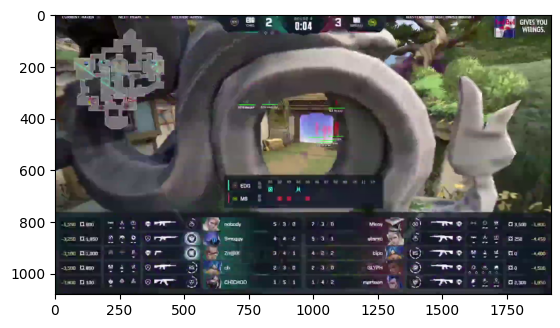

In [38]:
plt.imshow(frame)
plt.show()

In [36]:
texts

{'timer_sec': 29.0,
 'timer_texts': ['0;80', '0;80', '0.29', '0.29', '0.29'],
 'timer_secs': [29.0, 29.0, 29.0]}

In [19]:
df[df["search_start_sec"].isnull()]

,value,start_sec,end_sec,n_samples,mean_diff,min_diff,max_diff,duration_sec,t_sec,t_min,...,action_candidate,fix_applied,needs_review,map,start_timer_sec,start_search_offset_sec,search_start_sec,start_timer_raws,attacker_win,defender_win
31,True,3970.967,4025.021,55,25.429773,22.122803,26.82015,54.054,3970.967,66.182783,...,keep,NaN,False,PEARL,NaN,NaN,NaN,[],0,1


In [39]:
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    print(df["search_start_sec"].to_string())


0       23.009
1      111.106
2      237.235
3      310.297
4      428.421
5      545.542
6      753.736
7      895.895
8     1005.991
9     1179.169
10    1303.300
11    1428.420
12    1641.616
13    1719.713
14    1823.813
15    1952.948
16    2172.151
17    2252.242
18    2370.366
19    2452.449
20    2681.663
21    2796.793
22    3001.983
23    3132.122
24    3254.239
25    3318.310
26    3401.895
27    3512.504
28    3598.590
29    3735.729
30    3833.829
31         NaN
32    4069.051
33    4185.551
34    4375.854
35    4515.500
36    4731.703
37    4879.875
38    5022.017
39    5159.145
40    5360.339
41    5469.464
42    5681.674
43    5797.791
